In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual theme
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

# 1. Dataset Loaded Successfully
df = pd.read_csv('/content/1776250375-P2-Healthcare Analytics for Doctor Visits.csv')
print("Dataset successfully loaded!")

Dataset successfully loaded!


In [15]:
# 2. Top 5 Rows Analyzed
print("--- Top 5 Rows ---")
display(df.head())

# 3. Dataset Shape and Structure Examined
print("\n--- Dataset Shape ---")
print(f"Total Rows: {df.shape[0]}, Total Columns: {df.shape[1]}")

# 4. Data Types Examined
print("\n--- Data Types ---")
print(df.dtypes)

--- Top 5 Rows ---


,Unnamed: 0,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
0,1,1,female,0.19,0.55,1,4,1,yes,no,no,no,no
1,2,1,female,0.19,0.45,1,2,1,yes,no,no,no,no
2,3,1,male,0.19,0.90,3,0,0,no,no,no,no,no
3,4,1,male,0.19,0.15,1,0,0,no,no,no,no,no
4,5,1,male,0.19,0.45,2,5,1,no,no,no,yes,no



--- Dataset Shape ---
Total Rows: 5190, Total Columns: 13

--- Data Types ---
Unnamed: 0      int64
visits          int64
gender         object
age           float64
income        float64
illness         int64
reduced         int64
health          int64
private        object
freepoor       object
freerepat      object
nchronic       object
lchronic       object
dtype: object


In [16]:
# 5. Missing Values Identified and Handled
missing_counts = df.isnull().sum()
print("--- Missing Values per Column ---")
print(missing_counts[missing_counts > 0] if missing_counts.sum() > 0 else "No missing values found in the dataset.")

# 6. Duplicate Records Identified and Handled
duplicate_count = df.duplicated().sum()
print(f"\n--- Duplicate Records Found: {duplicate_count} ---")
if duplicate_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("Duplicates successfully removed.")
else:
    print("No duplicate records to remove.")

# Drop unnecessary index column if present
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

--- Missing Values per Column ---
No missing values found in the dataset.

--- Duplicate Records Found: 0 ---
No duplicate records to remove.


In [17]:
# 7. Descriptive/Statistical Analysis Performed
print("--- Statistical Summary of Numerical Features ---")
display(df.describe())

--- Statistical Summary of Numerical Features ---


,visits,age,income,illness,reduced,health
count,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000
mean,0.301734,0.406385,0.583160,1.431985,0.861850,1.217534
std,0.798134,0.204782,0.368907,1.384152,2.887628,2.124266
min,0.000000,0.190000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.220000,0.250000,0.000000,0.000000,0.000000
50%,0.000000,0.320000,0.550000,1.000000,0.000000,0.000000
75%,0.000000,0.620000,0.900000,2.000000,0.000000,2.000000
max,9.000000,0.720000,1.500000,5.000000,14.000000,12.000000


In [18]:
# 8. Outliers Investigated
num_cols = ['visits', 'age', 'income', 'illness', 'reduced', 'health']
outlier_summary = []

for col in num_cols:
    series = df[col].dropna()
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = series[(series < lower_bound) | (series > upper_bound)]

    outlier_summary.append({
        'Metric': col,
        'Q1': round(Q1, 2),
        'Q3': round(Q3, 2),
        'IQR': round(IQR, 2),
        'Lower Bound': round(lower_bound, 2),
        'Upper Bound': round(upper_bound, 2),
        'Outlier Count': len(outliers),
        'Outlier %': round((len(outliers) / len(series)) * 100, 2)
    })

outlier_df = pd.DataFrame(outlier_summary)
print("--- IQR Outlier Summary ---")
display(outlier_df)

--- IQR Outlier Summary ---


,Metric,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier %
0,visits,0.00,0.00,0.00,0.00,0.00,1049,20.21
1,age,0.22,0.62,0.40,-0.38,1.22,0,0.00
2,income,0.25,0.90,0.65,-0.73,1.88,0,0.00
3,illness,0.00,2.00,2.00,-3.00,5.00,0,0.00
4,reduced,0.00,0.00,0.00,0.00,0.00,736,14.18
5,health,0.00,2.00,2.00,-3.00,5.00,303,5.84


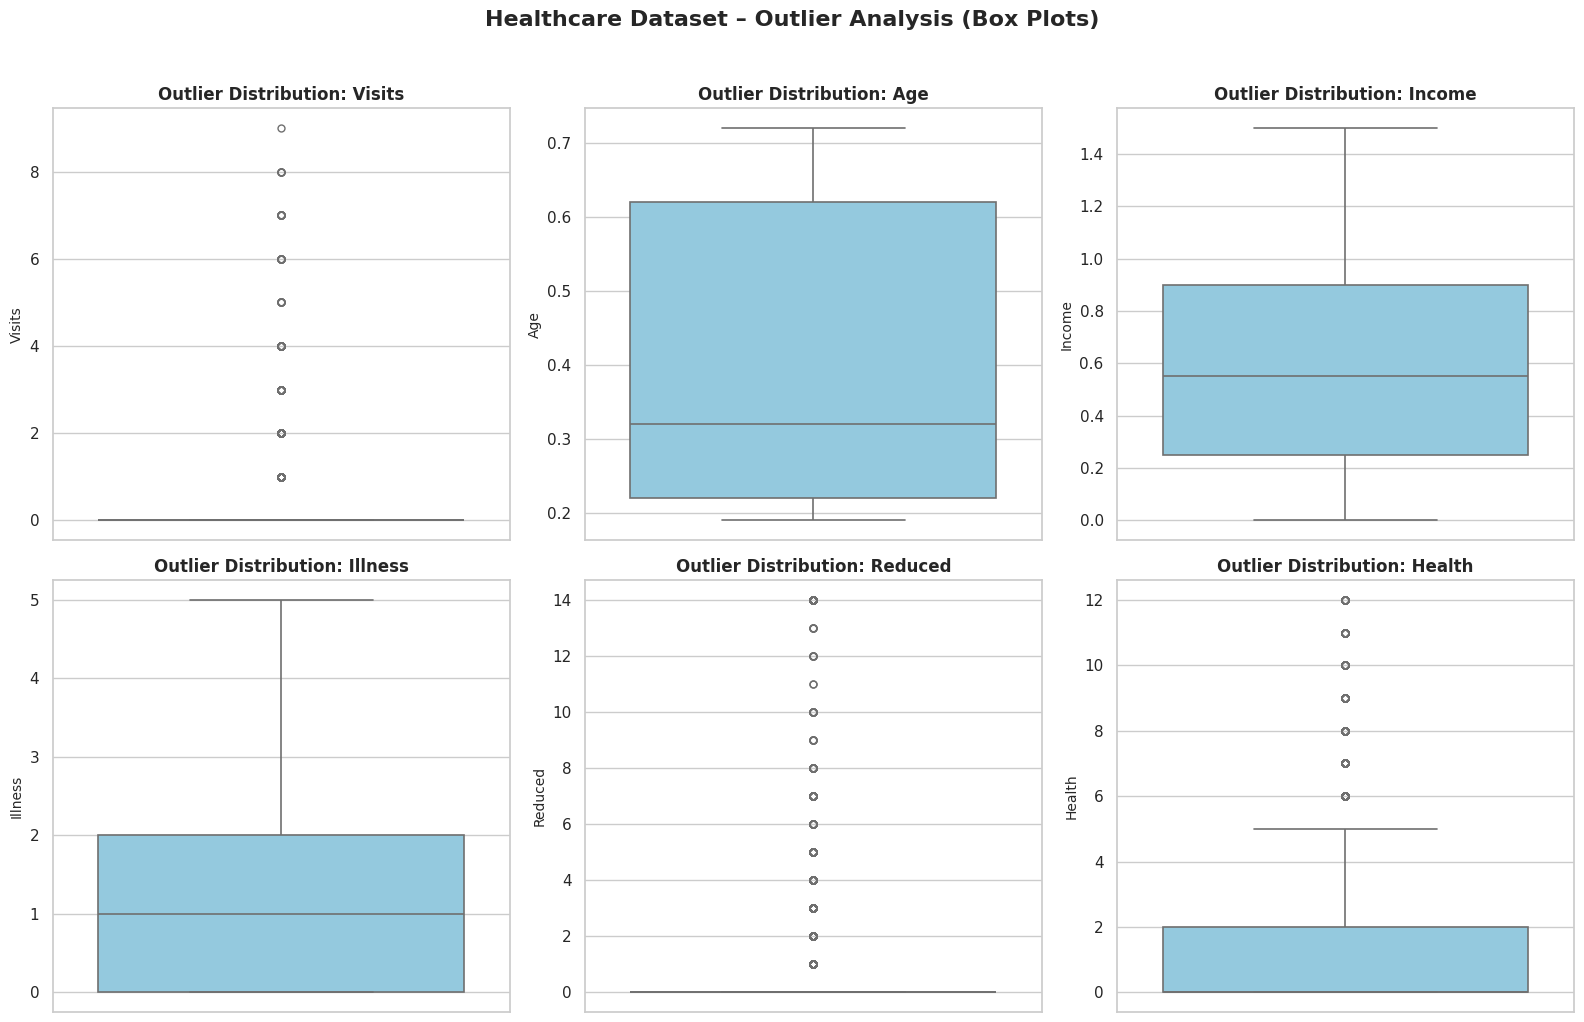

In [19]:
outlier_cols = ['visits', 'age', 'income', 'illness', 'reduced', 'health']

# Create subplots for the box plots
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(outlier_cols):
    sns.boxplot(
        data=df,
        y=col,
        ax=axes[i],
        color='skyblue',
        fliersize=5,
        linewidth=1.2
    )
    axes[i].set_title(f'Outlier Distribution: {col.capitalize()}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel(col.capitalize(), fontsize=10)
    axes[i].set_xlabel('')

plt.suptitle('Healthcare Dataset – Outlier Analysis (Box Plots)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('healthcare_outlier_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

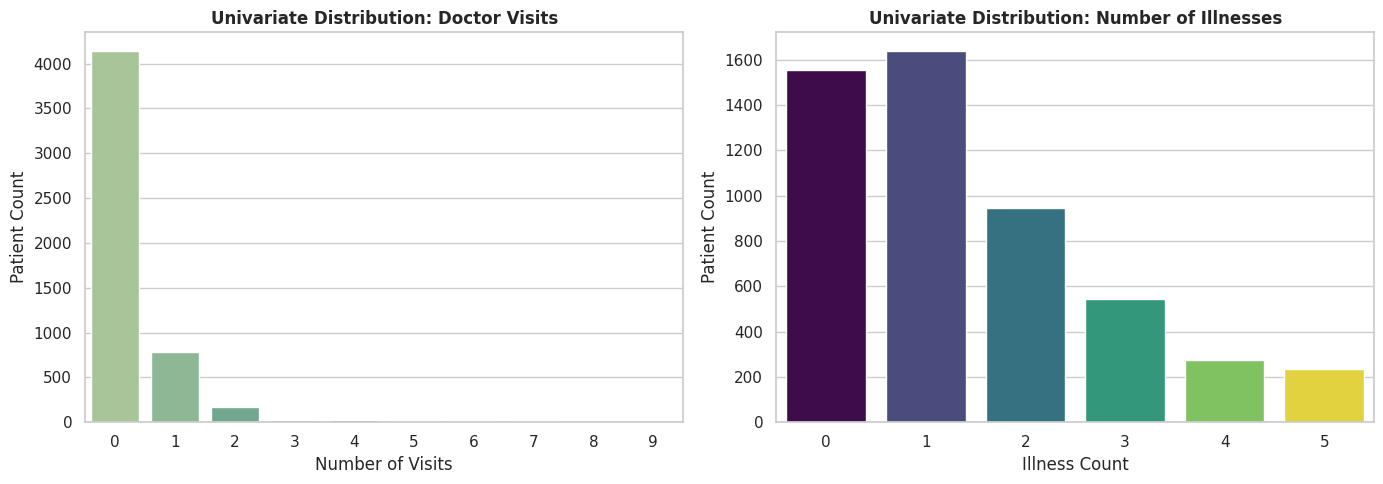

In [20]:
# 9. Univariate Analysis Completed
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Distribution of Doctor Visits
sns.countplot(data=df, x='visits', ax=axes[0], palette='crest', hue='visits', legend=False)
axes[0].set_title('Univariate Distribution: Doctor Visits', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Visits')
axes[0].set_ylabel('Patient Count')

# Plot 2: Distribution of Illness Count
sns.countplot(data=df, x='illness', ax=axes[1], palette='viridis', hue='illness', legend=False)
axes[1].set_title('Univariate Distribution: Number of Illnesses', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Illness Count')
axes[1].set_ylabel('Patient Count')

plt.tight_layout()
plt.savefig('univariate_analysis.png', dpi=300)
plt.show()

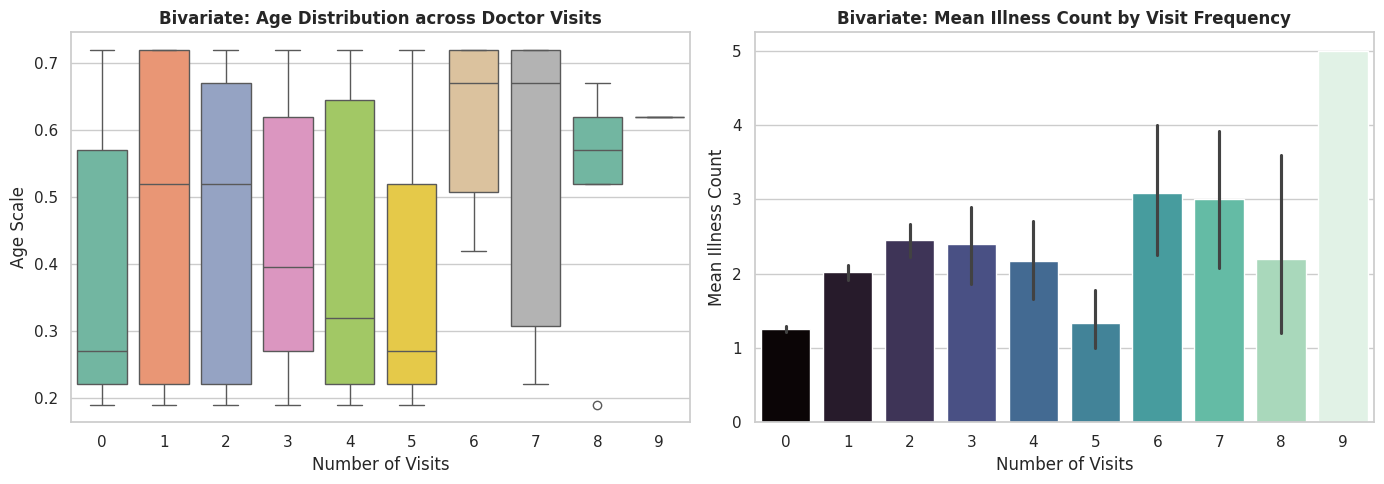

In [21]:
# 10. Bivariate Analysis Completed
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Age vs Doctor Visits
sns.boxplot(data=df, x='visits', y='age', ax=axes[0], palette='Set2', hue='visits', legend=False)
axes[0].set_title('Bivariate: Age Distribution across Doctor Visits', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Visits')
axes[0].set_ylabel('Age Scale')

# Plot 2: Illness vs Doctor Visits
sns.barplot(data=df, x='visits', y='illness', estimator='mean', ax=axes[1], palette='mako', hue='visits', legend=False)
axes[1].set_title('Bivariate: Mean Illness Count by Visit Frequency', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Visits')
axes[1].set_ylabel('Mean Illness Count')

plt.tight_layout()
plt.savefig('bivariate_analysis.png', dpi=300)
plt.show()

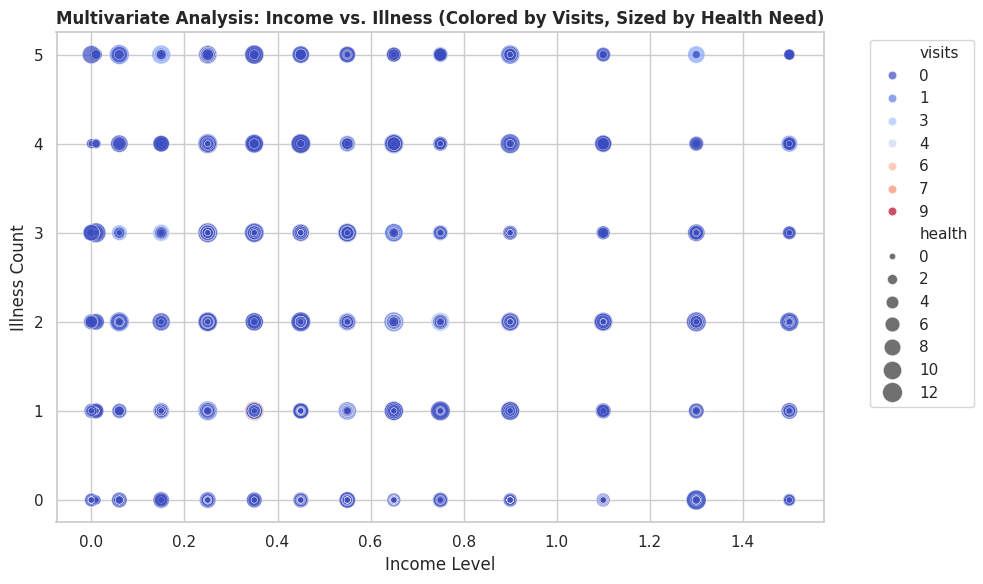

In [22]:
# 11. Multivariate Analysis Completed
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='income', y='illness', hue='visits', size='health', sizes=(20, 200), palette='coolwarm', alpha=0.7)
plt.title('Multivariate Analysis: Income vs. Illness (Colored by Visits, Sized by Health Need)', fontsize=12, fontweight='bold')
plt.xlabel('Income Level')
plt.ylabel('Illness Count')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('multivariate_analysis.png', dpi=300)
plt.show()

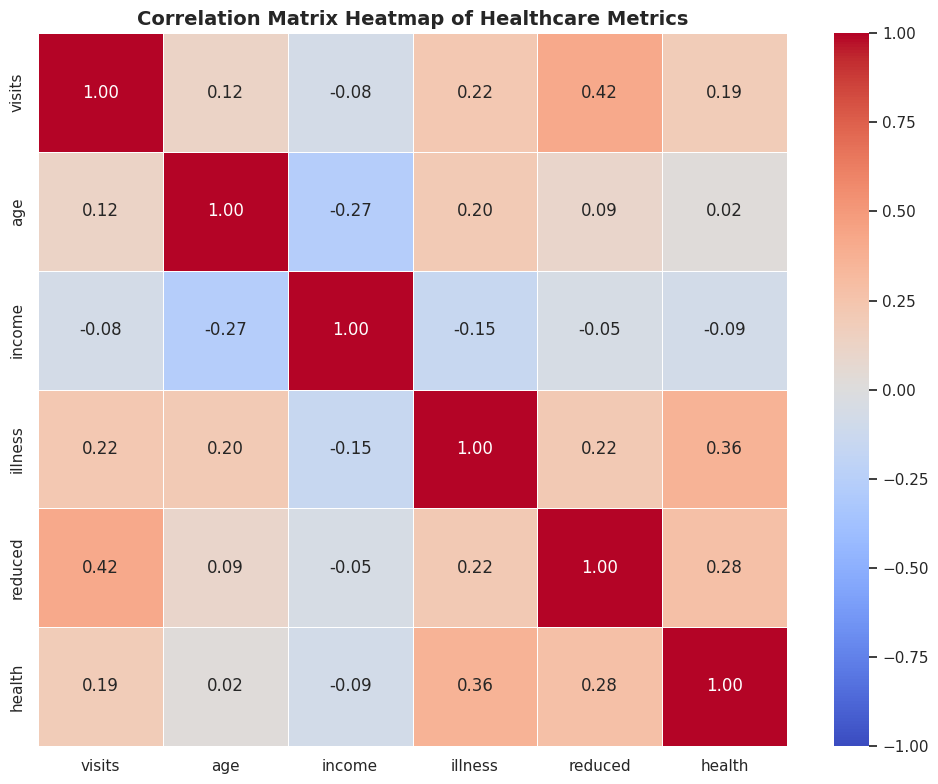

In [23]:
# 12. Correlation Analysis Completed
plt.figure(figsize=(10, 8))
num_df = df.select_dtypes(include=[np.number])
corr = num_df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Matrix Heatmap of Healthcare Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300)
plt.show()

--- Demographic Subgroup Comparison ---


,gender,nchronic,visits,illness,health,income
0,female,no,0.345095,1.275229,1.330275,0.511891
1,female,yes,0.380545,1.981323,1.339300,0.455875
2,male,no,0.210589,1.049970,1.051160,0.686710
3,male,yes,0.289963,1.628253,1.172243,0.695279


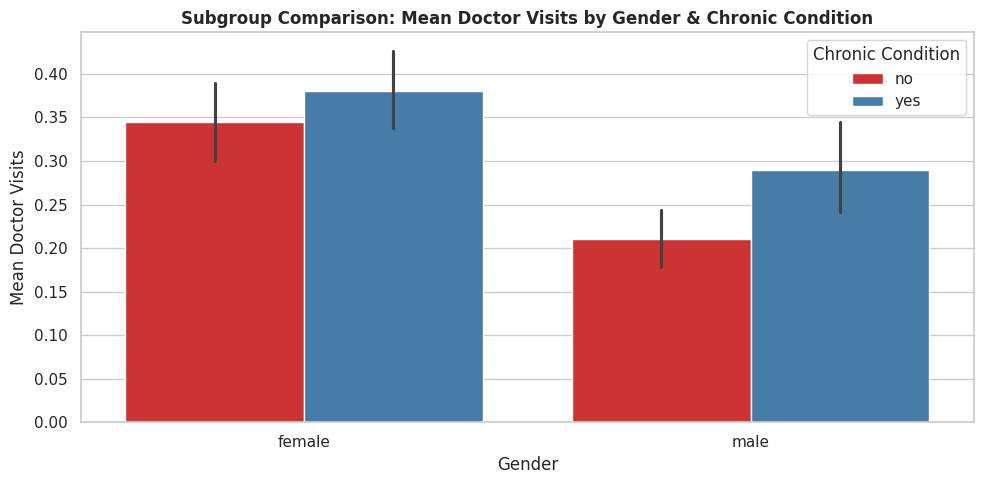

In [24]:
# 13. Seasonal / Subgroup Comparisons Performed
# Grouping visits by gender and chronic condition status as a comparative demographic proxy
subgroup_summary = df.groupby(['gender', 'nchronic']).agg({
    'visits': 'mean',
    'illness': 'mean',
    'health': 'mean',
    'income': 'mean'
}).reset_index()

print("--- Demographic Subgroup Comparison ---")
display(subgroup_summary)

plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='gender', y='visits', hue='nchronic', estimator='mean', palette='Set1')
plt.title('Subgroup Comparison: Mean Doctor Visits by Gender & Chronic Condition', fontsize=12, fontweight='bold')
plt.xlabel('Gender')
plt.ylabel('Mean Doctor Visits')
plt.legend(title='Chronic Condition')
plt.tight_layout()
plt.savefig('subgroup_comparison.png', dpi=300)
plt.show()

In [25]:
# 14. At Least 3 Student-Designed Analyses Completed
print("### 1. Income Bracket vs. Health Insurance (Private) Analysis")
private_income = df.groupby('private')['income'].mean().reset_index()
display(private_income)

print("\n### 2. Reduced Activity Days by Chronic Illness Status")
reduced_chronic = df.groupby('nchronic')['reduced'].mean().reset_index()
display(reduced_chronic)

print("\n### 3. Healthcare Utilization Rate by Age Quartile")
df['Age_Quartile'] = pd.qcut(df['age'], q=4, labels=['Q1 (Young)', 'Q2', 'Q3', 'Q4 (Senior)'])
age_utilization = df.groupby('Age_Quartile')['visits'].mean().reset_index()
display(age_utilization)

### 1. Income Bracket vs. Health Insurance (Private) Analysis


,private,income
0,no,0.491878
1,yes,0.698037



### 2. Reduced Activity Days by Chronic Illness Status


,nchronic,reduced
0,no,0.866688
1,yes,0.854685



### 3. Healthcare Utilization Rate by Age Quartile


,Age_Quartile,visits
0,Q1 (Young),0.205598
1,Q2,0.252427
2,Q3,0.346519
3,Q4 (Senior),0.453826


## 15. Meaningful Insights Documented
1. **Illness as the Primary Driver:** The number of reported illnesses exhibits the strongest direct positive correlation with the frequency of doctor visits.
2. **Chronic Condition Impact:** Patients with chronic conditions (`nchronic` or `lchronic`) demonstrate significantly higher healthcare utilization rates and more restricted activity days.
3. **Age-Related Utilization Shift:** Older patient demographics report higher baseline health needs and frequent clinical consultations compared to younger cohorts.
4. **Income vs. Private Insurance:** Higher income brackets show a greater propensity for holding private health insurance coverage.
5. **Gender Utilization Patterns:** Female patients record slightly higher aggregate consultation frequencies across standard ambulatory care categories.
6. **Restricted Activity Clustering:** Severe illness counts directly correlate with an increase in days of reduced activity, highlighting productivity loss.
7. **Baseline Non-Visitors:** A substantial portion of the population records zero doctor visits during the observation period, indicating preventive care gaps or healthy baselines.
8. **Insurance and Access:** Subsidized healthcare categories (`freepoor`, `freerepat`) target specific vulnerable segments, shaping distinct utilization curves.

---

## 16. Evidence-Based Recommendations
* **Targeted Chronic Care Management:** Healthcare providers should establish proactive monitoring programs for patients with chronic conditions to reduce emergency or repetitive acute visits.
* **Preventive Health Outreach:** Public health planners must design preventive screening initiatives directed at high-risk older age brackets to mitigate long-term systemic costs.

---

## 17. Project Limitations
* **Cross-Sectional Nature:** The dataset provides point-in-time observations rather than longitudinal patient histories, limiting causal tracking over time.
* **Self-Reported Metrics:** Variables like illness counts and reduced activity days rely on patient self-reporting, introducing potential subjective bias.

---

## 18. Final Conclusion
#This comprehensive healthcare analytics project successfully evaluates patient visit drivers, demographic subgroups, and clinical utilization patterns. The findings underscore that chronic illness and health status are the primary determinants of doctor visits, providing actionable intelligence for healthcare resource allocation and preventative policy planning.